In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

os.makedirs('data', exist_ok=True)

# Load dataset
df = pd.read_csv('../Data/group5-adult.csv')
df.replace('?', np.nan, inplace=True)
df['income'] = df['income'].str.strip()
df['income'] = (df['income'] == '>50K').astype(int)

# Define columns
numeric_cols     = ['age', 'fnlwgt', 'education-num',
                    'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status',
                    'occupation', 'relationship', 'race',
                    'sex', 'native-country']

X = df[numeric_cols + categorical_cols]
y = df['income']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Fit preprocessor
preprocessor.fit(X_train)

# Save everything
joblib.dump((X_train, X_test, y_train, y_test), 'data/train_test_split.pkl')
joblib.dump(preprocessor, 'data/preprocessor.pkl')
joblib.dump(numeric_cols, 'data/numeric_cols.pkl')
joblib.dump(categorical_cols, 'data/categorical_cols.pkl')

print("pkl files regenerated successfully!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

pkl files regenerated successfully!
X_train: (23508, 14) | X_test: (5877, 14)


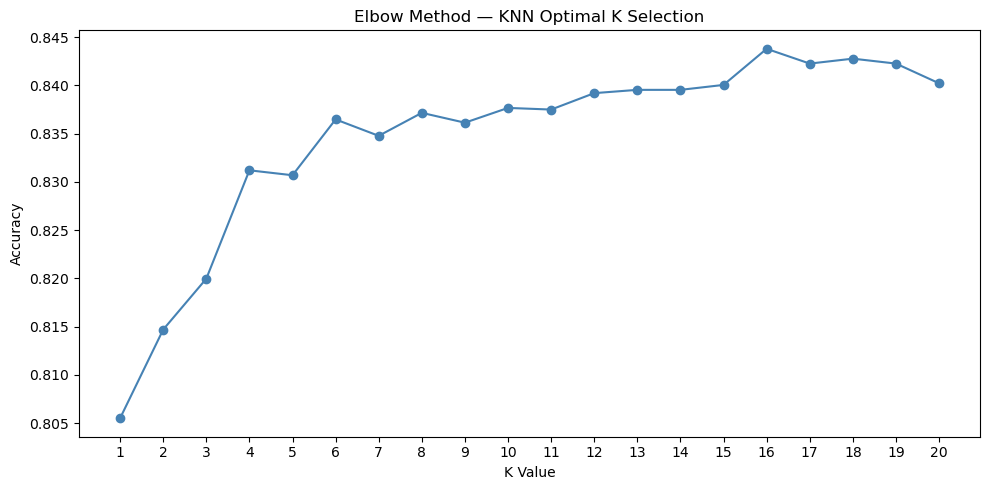

Best K: 16 | Best Accuracy: 0.8438


In [2]:
import time, tracemalloc
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Elbow Method — KNN Optimal K Selection')
plt.xticks(k_values)
plt.tight_layout()
plt.savefig('data/knn_elbow.png', dpi=150)
plt.show()

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k} | Best Accuracy: {max(accuracies):.4f}")

In [3]:
from sklearn.metrics import (roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

tracemalloc.start()
start_time = time.time()
knn_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time
current, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_pred = knn_pipeline.predict(X_test)
y_prob = knn_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("KNN — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['<=50K', '>50K']))
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak_mem / 1024:.2f} KB")
print("=" * 55)

KNN — CLASSIFICATION REPORT
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4466
        >50K       0.72      0.57      0.64      1411

    accuracy                           0.84      5877
   macro avg       0.80      0.75      0.77      5877
weighted avg       0.84      0.84      0.84      5877

Accuracy  : 0.8438
ROC-AUC   : 0.8870
Train Time: 0.1235s
Peak Mem  : 39340.68 KB


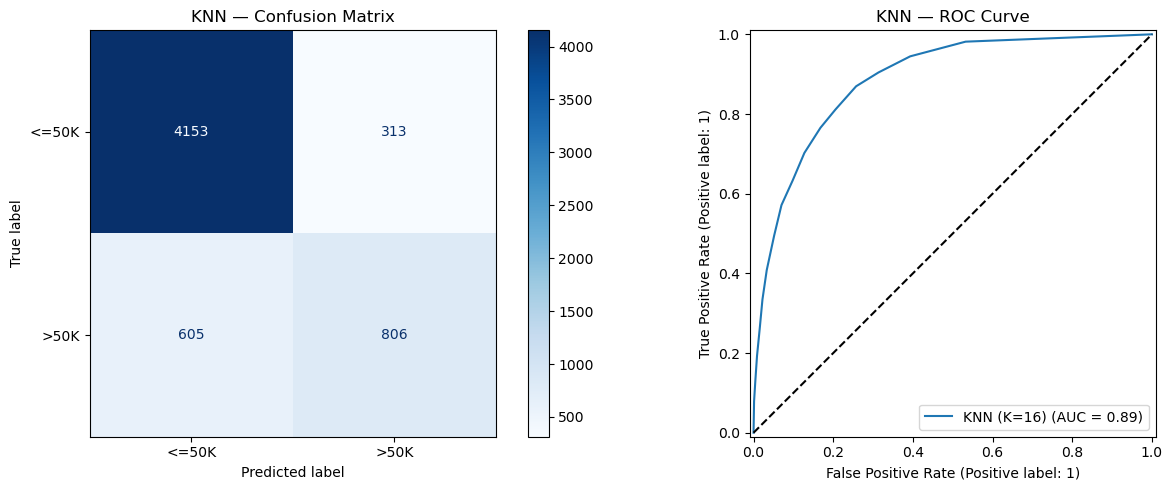

Plots saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    knn_pipeline, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('KNN — Confusion Matrix')

RocCurveDisplay.from_estimator(
    knn_pipeline, X_test, y_test,
    ax=axes[1], name=f'KNN (K={best_k})'
)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('KNN — ROC Curve')

plt.tight_layout()
plt.savefig('data/knn_plots.png', dpi=150)
plt.show()
print("Plots saved!")

In [5]:
joblib.dump(knn_pipeline, 'data/knn_model.pkl')

start_pred = time.time()
_ = knn_pipeline.predict(X_test)
pred_time = round(time.time() - start_pred, 4)

knn_results = {
    'model_name'  : 'KNN',
    'accuracy'    : round(accuracy_score(y_test, y_pred), 4),
    'roc_auc'     : round(roc_auc_score(y_test, y_prob), 4),
    'train_time'  : round(train_time, 4),
    'peak_mem_kb' : round(peak_mem / 1024, 2),
    'pred_time'   : pred_time
}

joblib.dump(knn_results, 'data/knn_results.pkl')
print("KNN model and results saved!")
print(knn_results)

KNN model and results saved!
{'model_name': 'KNN', 'accuracy': 0.8438, 'roc_auc': np.float64(0.887), 'train_time': 0.1235, 'peak_mem_kb': 39340.68, 'pred_time': 0.1991}
